## Part 2: the language models

In [82]:
# Part 2 — Language Models

# 1. Configuration

# 2. Load tokenizers

## 3. Prepare LM datasets

## 4. Transformer architecture

## 5. Parameter counts

## 6. Training utilities

## 7. Sanity checks / tiny overfit

## 8. Character model training

## 9. BPE-3k model training

## 10. BPE-10k model training

## 11. Learning curves

## 12. Preliminary observations

In [83]:
# imports

from pathlib import Path
import json
import torch
import sentencepiece as spm

DATA_DIR = Path("/srv/data/lt2326-h26/a1")

PROJECT_DIR = Path.cwd().parent
TOKENIZER_DIR = PROJECT_DIR / "artifacts" / "tokenizers"
MODEL_DIR = PROJECT_DIR / "artifacts" / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA A30


In [84]:
## Re-loading character tokenizer

with open(TOKENIZER_DIR / "char_vocab.json", encoding="utf-8") as f:
    char_vocab = json.load(f)

char_to_id = {char: i for i, char in enumerate(char_vocab)}

id_to_char = {i: char for i, char in enumerate(char_vocab)}

## Re-creating character encoder

def encode(text):
    token_ids = []

    for char in text:
        if char in char_to_id:
            token_id = char_to_id[char]
        else:
            token_id = char_to_id.get("<unk>", 0) # fallback for <unk>
        token_ids.append(token_id)

    return token_ids

print("Character vocab:", len(char_vocab))
print("UNK:", char_to_id["<unk>"])

Character vocab: 9443
UNK: 0


In [85]:
## Re-loading the BPE tokenizers

small_bpe = spm.SentencePieceProcessor(
    model_file=str(TOKENIZER_DIR / "small_bpe.model")
)

large_bpe = spm.SentencePieceProcessor(
    model_file=str(TOKENIZER_DIR / "large_bpe.model")
)

print("Character:", len(char_vocab))
print("Small BPE:", small_bpe.vocab_size())
print("Large BPE:", large_bpe.vocab_size())

text = "This is a test."

Character: 9443
Small BPE: 3000
Large BPE: 10000


In [86]:
## Encoding wrappers

def encode_char(text):
    return encode(text)

def encode_small_bpe(text):
    return small_bpe.encode(text, out_type=int)

def encode_large_bpe(text):
    return large_bpe.encode(text, out_type=int)

In [87]:
## Preparing to add eos to the vocab for each tokenizer ?????

# original vocab sizes
char_eos_id = len(char_vocab)
small_eos_id = small_bpe.vocab_size()
large_eos_id = large_bpe.vocab_size()

# vocab sizes with eos
char_lm_vocab_size = len(char_vocab) + 1
small_lm_vocab_size = small_bpe.vocab_size() + 1
large_lm_vocab_size = large_bpe.vocab_size() + 1

print("Character:", char_lm_vocab_size, "EOS:", char_eos_id)
print("BPE-3k:", small_lm_vocab_size, "EOS:", small_eos_id)
print("BPE-10k:", large_lm_vocab_size, "EOS:", large_eos_id)

Character: 9444 EOS: 9443
BPE-3k: 3001 EOS: 3000
BPE-10k: 10001 EOS: 10000


In [88]:
## Building token stream + adding eos to the vocab

def build_token_stream(data_path, encode_fn, eos_id):
    token_ids = [] # building one continuous list
    
    with open(data_path, encoding="utf-8") as f:
        for line in f:
            sentence = line.rstrip("\n")
            encoded_ids = encode_fn(sentence)

            token_ids.extend(encoded_ids)
            token_ids.append(eos_id)


    return token_ids

In [89]:
## shuffling data

# ... or not? if using balanced.txt instead ???

In [90]:
# tokenizer conditions
tokenizers = {
    "Character": {
        "encode_fn": encode_char,
        "eos_id": char_eos_id,
        "vocab_size": char_lm_vocab_size,
    },
    "BPE-3k": {
        "encode_fn": encode_small_bpe,
        "eos_id": small_eos_id,
        "vocab_size": small_lm_vocab_size,
    },
    "BPE-10k": {
        "encode_fn": encode_large_bpe,
        "eos_id": large_eos_id,
        "vocab_size": large_lm_vocab_size,
    },
}

## building training streams for every tokenizer from balanced.txt

train_path = DATA_DIR / "tokenizer" / "balanced.txt"

train_streams = {}

for tokenizer_name, config in tokenizers.items():
    train_streams[tokenizer_name] = build_token_stream(
        data_path=train_path,
        encode_fn=config["encode_fn"],
        eos_id=config["eos_id"],
    )

In [91]:
# sanity checking training streams

for name in train_streams:
    train_streams[name] = torch.tensor(
        train_streams[name],
        dtype=torch.long
    )

for name, stream in train_streams.items():
    print(
        name,
        "tokens:", len(stream),
        "min ID:", stream.min().item(),
        "max ID:", stream.max().item(),
        "LM vocab size:", tokenizers[name]["vocab_size"],
    )

Character tokens: 8980877 min ID: 1 max ID: 9443 LM vocab size: 9444
BPE-3k tokens: 6780586 min ID: 0 max ID: 3000 LM vocab size: 3001
BPE-10k tokens: 4221411 min ID: 0 max ID: 10000 LM vocab size: 10001


In [92]:
## validation streams

# encoding all the files
def build_valid_token_stream(file_paths, encode_fn, eos_id):
    token_ids = []

    for path in file_paths:
        with open(path, encoding="utf-8") as f:
            for line in f:
                sentence = line.rstrip("\n")
                encoded_ids = encode_fn(sentence)

                token_ids.extend(encoded_ids)
                token_ids.append(eos_id)

    return torch.tensor(token_ids, dtype=torch.long)

valid_paths = [
    DATA_DIR / "valid" / "en.txt",
    DATA_DIR / "valid" / "tr.txt",
    DATA_DIR / "valid" / "zh.txt",
]

# building the streams
valid_streams = {}

for name, config in tokenizers.items():
    valid_streams[name] = build_valid_token_stream(
        file_paths=valid_paths,
        encode_fn=config["encode_fn"],
        eos_id=config["eos_id"],
    )

# sanity checking
for name, stream in valid_streams.items():
    print(
        name,
        "validation tokens:", len(stream),
        "min:", stream.min().item(),
        "max:", stream.max().item(),
    )

Character validation tokens: 1122747 min: 0 max: 9443
BPE-3k validation tokens: 848225 min: 0 max: 3000
BPE-10k validation tokens: 529970 min: 0 max: 10000


In [93]:
## Building custom dataset
from torch.utils.data import Dataset

# defining token windows
class CostumDataset(Dataset):
    def __init__(self, token_stream, context_length):
        self.token_stream = token_stream
        self.context_length = context_length

    def __len__(self):
        return (len(self.token_stream) -1) // self.context_length # number of possible starting points

    def __getitem__(self, idx):
        start = idx * self.context_length
        end = start + self.context_length

        x = self.token_stream[start:end]
        y = self.token_stream[start + 1:end + 1]

        return x, y

In [94]:
## ????

CONTEXT_LENGTH = 128

train_datasets = {}

for name, stream in train_streams.items():
    train_datasets[name] = CostumDataset(
        token_stream=stream,
        context_length= CONTEXT_LENGTH,
    )

for name, dataset in train_datasets.items():
    print(name, "windows:", len(dataset))

Character windows: 70163
BPE-3k windows: 52973
BPE-10k windows: 32979


In [95]:
## Dataloader for training data

from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loaders = {}

for name, dataset in train_datasets.items():
    train_loaders[name] = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

# sanity checking
x, y = next(iter(train_loaders["BPE-3k"]))

print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

x: torch.Size([64, 128]) torch.int64
y: torch.Size([64, 128]) torch.int64


In [96]:
## ???

valid_datasets = {}

for name, stream in valid_streams.items():
    valid_datasets[name] = CostumDataset(
        token_stream=stream,
        context_length=CONTEXT_LENGTH,
    )

valid_loaders = {}

for name, dataset in valid_datasets.items():
    valid_loaders[name] = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

# sanity checking
for name in tokenizers:
    train_x, train_y = next(iter(train_loaders[name]))
    valid_x, valid_y = next(iter(valid_loaders[name]))

    print(
        name,
        "train:", train_x.shape,
        "valid:", valid_x.shape
    )

Character train: torch.Size([64, 128]) valid: torch.Size([64, 128])
BPE-3k train: torch.Size([64, 128]) valid: torch.Size([64, 128])
BPE-10k train: torch.Size([64, 128]) valid: torch.Size([64, 128])


In [97]:
## Transformer

import torch.nn as nn

class TransformerLM(nn.Module):
    def __init__(
            self,
            vocab_size,
            context_length=128,
            d_model=256,
            n_heads=4,
            n_layers=2,
            dim_feedforward=1024,
            dropout=0.1,
    ):
        super().__init__()

        self.context_length = context_length

        # turning each token ID into a d_model-dimensional vector
        self.token_embedding = nn.Embedding(
            vocab_size,
            d_model
        )   # embedding matrix for e.g. 3k [3001, 256]

        # giving each position its own learned representation
        self.position_embedding = nn.Embedding(
            context_length,
            d_model
        )   # representing position 0 to 127

        # one transformer block
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )

        # stacking n_layers transformer blocks
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
        )

        # converting hidden representations into vocabulary scores
        self.output_layer = nn.Linear(
            d_model,
            vocab_size
        )   # for e.g. 3k [256, 3001] (produces 3001 scores for possible next token at each position)

    def forward(self, x):

        batch_size, seq_length = x.shape

        # token representations
        token_emb = self.token_embedding(x)

        # positions: 0, 1 ..., seq_lenth -1
        positions = torch.arange(
            seq_length,
            device=x.device
        )

        position_emb = self.position_embedding(positions)

        # combininb token identity and position info
        h = token_emb + position_emb

        # preventing attention to future positions (causal mask)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(
            seq_length,
            device=x.device
        )

        h = self.transformer(
            h,
            mask=causal_mask
        )

        # scores over the vocabulary ?????
        logits = self.output_layer(h)

        return logits

In [98]:
## parameter count ????

def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
    )

for name, model in models.items():
    print(name, f"{count_parameters(model):,}")

def count_embedding_parameters(model):
    return model.token_embedding.weight.numel()

def count_output_parameters(model):
    return sum(
        p.numel()
        for p in model.output_layer.parameters()
    )

# putting the results in a table
parameter_results = []

for name, model in models.items():
    parameter_results.append({
        "model": name,
        "vocab_size": tokenizers[name]["vocab_size"],
        "total_parameters": count_parameters(model),
        "embedding_parameters": count_embedding_parameters(model),
        "output_parameters": count_output_parameters(model),
    })

parameter_df = pd.DataFrame(parameter_results)
parameter_df

Character 6,457,060
BPE-3k 3,151,801
BPE-10k 6,742,801


,model,vocab_size,total_parameters,embedding_parameters,output_parameters
0,Character,9444,6457060,2417664,2427108
1,BPE-3k,3001,3151801,768256,771257
2,BPE-10k,10001,6742801,2560256,2570257


In [99]:
# evaluating model without training it

def evaluate_loss(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    num_batches = 0

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)

            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                y.reshape(-1)
            )

            total_loss += loss.item()
            num_batches += 1

    return total_loss / num_batches

In [100]:
# training one epoch

def train_one_epoch(model, data_loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    num_batches = 0

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            y.reshape(-1)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches

In [ ]:
# main training loop

EPOCHS = 5
LEARNING_RATE = 3e-4

def train_model(
    model,
    train_loader,
    valid_loader,
    epochs,
    learning_rate,
    device
):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate
    )

    history = {
        "train_loss": [],
        "valid_loss": []
    }

    for epoch in range(epochs):
        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device
        )

        valid_loss = evaluate_loss(
            model,
            valid_loader,
            criterion,
            device
        )

        history["train_loss"].append(train_loss)
        history["valid_loss"].append(valid_loss)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train: {train_loss:.4f} | "
            f"Valid: {valid_loss:.4f}"
        )

    return model, history

In [ ]:
# training the 3k model

bpe3k_model = TransformerLM(
    vocab_size=small_lm_vocab_size,
    context_length=CONTEXT_LENGTH,
    d_model=256,
    n_heads=4,
    n_layers=2,
    dim_feedforward=1024,
    dropout=0.1,
)

bpe3k_model, bpe3k_history = train_model(
    model=bpe3k_model,
    train_loader=train_loaders["BPE-3k"],
    valid_loader=valid_loaders["BPE-3k"],
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    device=device,
)

Epoch 1/5 | Train: 4.8108 | Valid: 4.2122
Epoch 2/5 | Train: 4.0778 | Valid: 3.8789
Epoch 3/5 | Train: 3.8444 | Valid: 3.7153
Epoch 4/5 | Train: 3.7116 | Valid: 3.6144
Epoch 5/5 | Train: 3.6237 | Valid: 3.5485


In [103]:
# saving the model

torch.save(
    {
        "model_state_dict": bpe3k_model.state_dict(),
        "history": bpe3k_history,
        "vocab_size": small_lm_vocab_size,
        "context_length": CONTEXT_LENGTH,
        "d_model": 256,
        "n_heads": 4,
        "n_layers": 2,
        "dim_feedforward": 1024,
        "dropout": 0.1,
    },
    MODEL_DIR / "bpe_3k_lm.pt"
)

In [104]:
# training the character-level model

char_model = TransformerLM(
    vocab_size=char_lm_vocab_size,
    context_length=CONTEXT_LENGTH,
    d_model=256,
    n_heads=4,
    n_layers=2,
    dim_feedforward=1024,
    dropout=0.1,
)

char_model, char_history = train_model(
    model=char_model,
    train_loader=train_loaders["Character"],
    valid_loader=valid_loaders["Character"],
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    device=device,
)

Epoch 1/5 | Train: 3.7963 | Valid: 3.2916
Epoch 2/5 | Train: 3.1775 | Valid: 3.0192
Epoch 3/5 | Train: 2.9894 | Valid: 2.8947
Epoch 4/5 | Train: 2.8876 | Valid: 2.8197
Epoch 5/5 | Train: 2.8195 | Valid: 2.7696


In [105]:
# saving the model

torch.save(
    {
        "model_state_dict": char_model.state_dict(),
        "history": char_history,
        "vocab_size": char_lm_vocab_size,
        "context_length": CONTEXT_LENGTH,
        "d_model": 256,
        "n_heads": 4,
        "n_layers": 2,
        "dim_feedforward": 1024,
        "dropout": 0.1,
    },
    MODEL_DIR / "char_lm.pt"
)

In [106]:
# trainign the 10k model

bpe10k_model = TransformerLM(
    vocab_size=large_lm_vocab_size,
    context_length=CONTEXT_LENGTH,
    d_model=256,
    n_heads=4,
    n_layers=2,
    dim_feedforward=1024,
    dropout=0.1,
)

bpe10k_model, bpe10k_history = train_model(
    model=bpe10k_model,
    train_loader=train_loaders["BPE-10k"],
    valid_loader=valid_loaders["BPE-10k"],
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    device=device,
)

Epoch 1/5 | Train: 7.3419 | Valid: 6.7233
Epoch 2/5 | Train: 6.5001 | Valid: 6.2224
Epoch 3/5 | Train: 6.0647 | Valid: 5.9037
Epoch 4/5 | Train: 5.7791 | Valid: 5.7078
Epoch 5/5 | Train: 5.5845 | Valid: 5.5809


In [107]:
# saving the model

torch.save(
    {
        "model_state_dict": bpe10k_model.state_dict(),
        "history": bpe10k_history,
        "vocab_size": large_lm_vocab_size,
        "context_length": CONTEXT_LENGTH,
        "d_model": 256,
        "n_heads": 4,
        "n_layers": 2,
        "dim_feedforward": 1024,
        "dropout": 0.1,
    },
    MODEL_DIR / "bpe_10k_lm.pt"
)

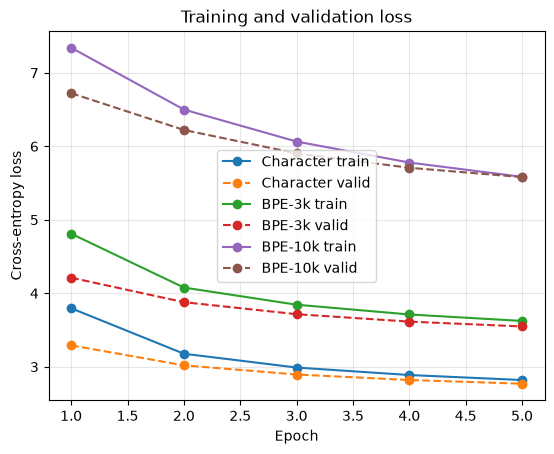

Character  | final train: 2.8195 | final valid: 2.7696
BPE-3k     | final train: 3.6237 | final valid: 3.5485
BPE-10k    | final train: 5.5845 | final valid: 5.5809


In [108]:
# plotting the learning curves

import matplotlib.pyplot as plt

histories = {
    "Character": char_history,
    "BPE-3k": bpe3k_history,
    "BPE-10k": bpe10k_history,
}

epochs = range(1, EPOCHS + 1)

for name, history in histories.items():
    plt.plot(
        epochs,
        history["train_loss"],
        marker="o",
        label=f"{name} train"
    )
    plt.plot(
        epochs,
        history["valid_loss"],
        marker="o",
        linestyle="--",
        label=f"{name} valid"
    )

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# printing final losses
for name, history in histories.items():
    print(
        f"{name:10} | "
        f"final train: {history['train_loss'][-1]:.4f} | "
        f"final valid: {history['valid_loss'][-1]:.4f}"
    )

Training setup:

- 2 Transformer layers
- d_model = 256
- 4 attention heads
- feed-forward dimension = 1024
- dropout = 0.1
- context length = 128
- learned positional embeddings

Training
- AdamW
- learning rate = 3e-4
- batch size = 64
- 5 epochs
- cross-entropy next-token prediction
- causal attention mask

Training-control policy
- Same number of epochs over the same underlying balanced training text.
- This means each model sees the same original text five times.
- Limitation: tokenizers produce different numbers of tokens, so computational
  cost per epoch differs.

Training token counts / epoch
- Character: 8,980,877
- BPE-3k: 6,780,586
- BPE-10k: 4,221,411